## FIRST PART:   FAULT CLASSIFICATION

In [5]:
import os
os.listdir('/content')

['.config',
 'Misalignment_state_2000rpm_10mins.jsonl',
 'Normal_state_2000rpm_10mins.jsonl',
 'Bearing_fault_state_2000rpm_10mins.jsonl',
 'Unbalance_state_2000rpm_10mins_with_4screws.jsonl',
 'Mechanical_looseness_state_2000rpm_10mins.jsonl',
 'sample_data']

In [6]:
import json
import numpy as np
import pandas as pd

files = {
     "Bearing_fault": "/content/Bearing_fault_state_2000rpm_10mins.jsonl",
    "Mechanical_looseness": "/content/Mechanical_looseness_state_2000rpm_10mins.jsonl",
    "Misalignment": "/content/Misalignment_state_2000rpm_10mins.jsonl",
    "Normal": "/content/Normal_state_2000rpm_10mins.jsonl",
    "Unbalance": "/content/Unbalance_state_2000rpm_10mins_with_4screws.jsonl"
}


def load_jsonl(path, label):
    rows = []
    with open(path, "r") as f:
        for line in f:
            obj = json.loads(line)
            rows.append({
                "time": obj["time"],
                "axis": obj["axis"],
                "data": np.array(obj["data"], dtype=float),
                "label": label
            })
    return rows

In [7]:
def build_triaxial_samples(rows):
    samples = []
    current = {}

    for row in rows:
        axis = row["axis"].upper()
        current[axis] = row["data"]

        if all(a in current for a in ["X", "Y", "Z"]):
            samples.append({
                "x": current["X"],
                "y": current["Y"],
                "z": current["Z"],
                "label": row["label"]
            })
            current = {}

    return samples

In [8]:
all_samples = []

for label, path in files.items():
    rows = load_jsonl(path, label)
    samples = build_triaxial_samples(rows)
    all_samples.extend(samples)
    print(label, len(samples))

Bearing_fault 689
Mechanical_looseness 710
Misalignment 706
Normal 504
Unbalance 488


In [9]:
# Step 3: Basic preprocessing checks

# check structure of first sample
print("Keys in first sample:", all_samples[0].keys())

# check lengths of x, y, z
lengths = []
for s in all_samples:
    lengths.append({
        "label": s["label"],
        "len_x": len(s["x"]),
        "len_y": len(s["y"]),
        "len_z": len(s["z"])
    })

length_df = pd.DataFrame(lengths)

print("Length summary:")
print(length_df[["len_x", "len_y", "len_z"]].describe())

print("\nAny missing axis lengths?")
print(length_df[["len_x", "len_y", "len_z"]].isna().sum())

print("\nUnique lengths in each axis:")
print("X:", length_df["len_x"].unique()[:10])
print("Y:", length_df["len_y"].unique()[:10])
print("Z:", length_df["len_z"].unique()[:10])

print("\nClass distribution:")
print(length_df["label"].value_counts())

Keys in first sample: dict_keys(['x', 'y', 'z', 'label'])
Length summary:
        len_x   len_y   len_z
count  3097.0  3097.0  3097.0
mean   1024.0  1024.0  1024.0
std       0.0     0.0     0.0
min    1024.0  1024.0  1024.0
25%    1024.0  1024.0  1024.0
50%    1024.0  1024.0  1024.0
75%    1024.0  1024.0  1024.0
max    1024.0  1024.0  1024.0

Any missing axis lengths?
len_x    0
len_y    0
len_z    0
dtype: int64

Unique lengths in each axis:
X: [1024]
Y: [1024]
Z: [1024]

Class distribution:
label
Mechanical_looseness    710
Misalignment            706
Bearing_fault           689
Normal                  504
Unbalance               488
Name: count, dtype: int64


In [10]:
# inspect first 2 samples
for i in range(2):
    print(f"\nSample {i}")
    print("Label:", all_samples[i]["label"])
    print("X first 5:", all_samples[i]["x"][:5])
    print("Y first 5:", all_samples[i]["y"][:5])
    print("Z first 5:", all_samples[i]["z"][:5])


Sample 0
Label: Bearing_fault
X first 5: [-251.46972656 -128.46972656 -617.46972656   73.53027344 -267.46972656]
Y first 5: [  10.74023438 -174.25976562  253.74023438  470.74023438  304.74023438]
Z first 5: [-145.16210938 -111.16210938   89.83789062  -51.16210938  233.83789062]

Sample 1
Label: Bearing_fault
X first 5: [-531.86621094 -991.86621094 -673.86621094 -465.86621094 -532.86621094]
Y first 5: [-121.16992188   17.83007812  138.83007812 -158.16992188  105.83007812]
Z first 5: [ 11.3828125 320.3828125 700.3828125 900.3828125 806.3828125]


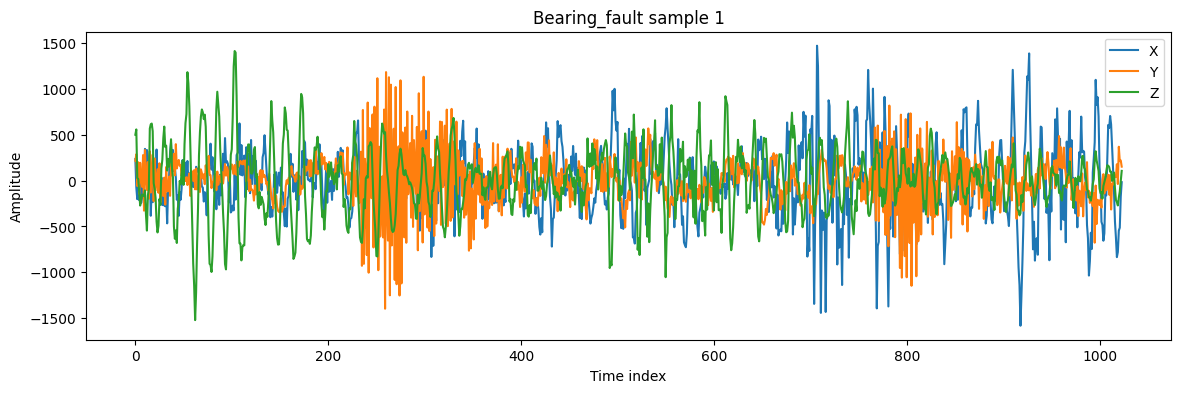

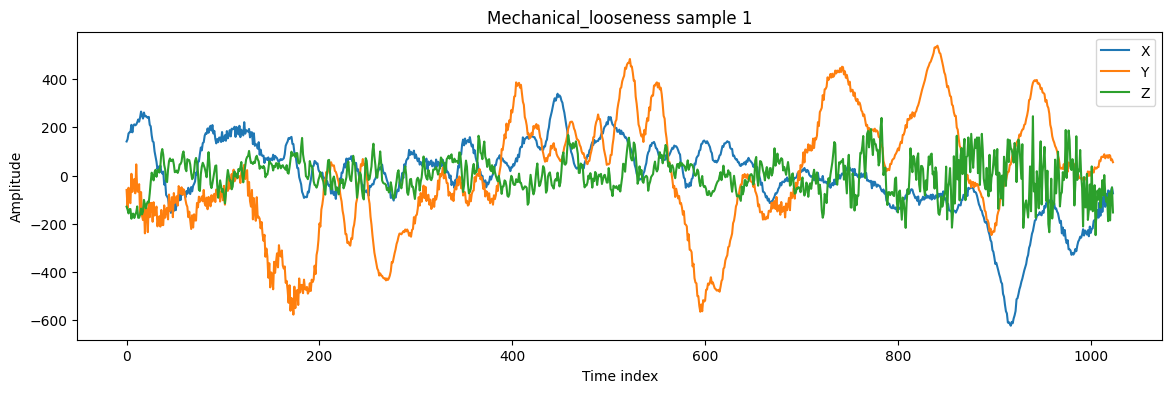

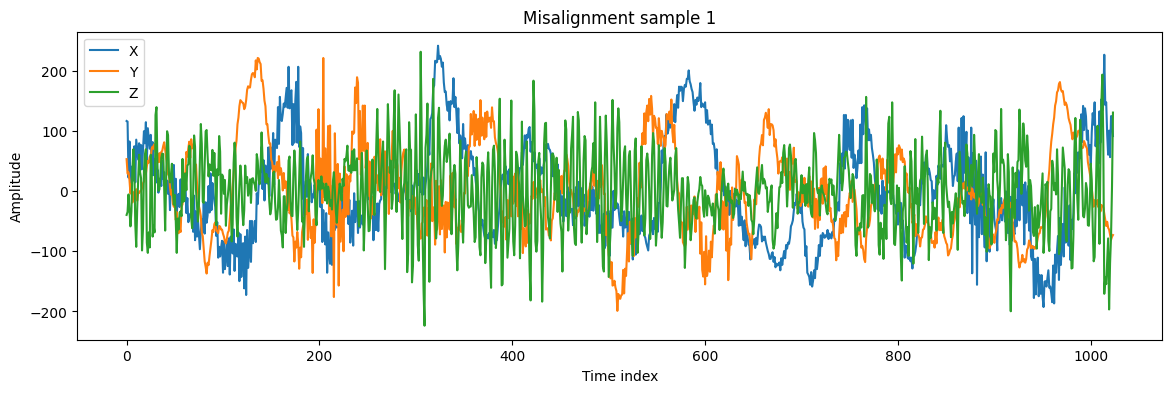

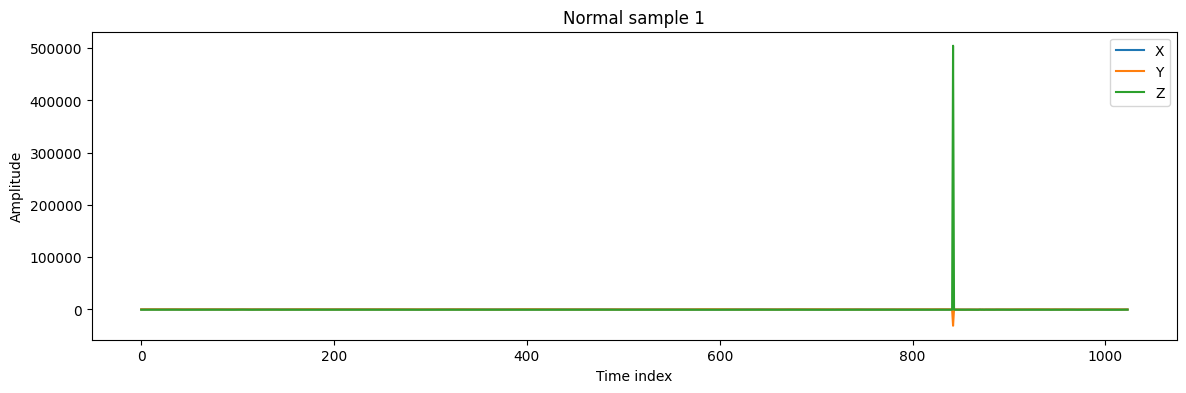

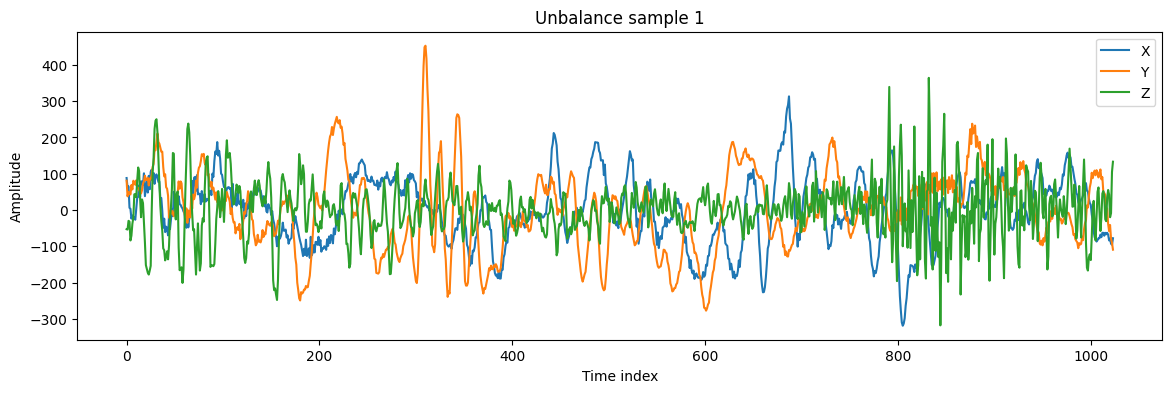

In [11]:
import matplotlib.pyplot as plt
import random

def plot_sample_waveforms(samples, label, n=1):
    subset = [s for s in samples if s["label"] == label]
    chosen = random.sample(subset, min(n, len(subset)))

    for i, s in enumerate(chosen, 1):
        plt.figure(figsize=(14, 4))
        plt.plot(s["x"], label="X")
        plt.plot(s["y"], label="Y")
        plt.plot(s["z"], label="Z")
        plt.title(f"{label} sample {i}")
        plt.xlabel("Time index")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.show()

for label in files.keys():
    plot_sample_waveforms(all_samples, label, n=1)

Bearing fault → high amplitude spikes, chaotic → high energy/kurtosis

Misalignment → smoother oscillatory pattern → more periodic

Normal → lower amplitude, more stable

Unbalance → some periodicity + spikes → overlaps with normal/misalignment

In [12]:
from scipy.stats import skew, kurtosis
import numpy as np
import pandas as pd

def zero_crossing_rate(x):
    return ((x[:-1] * x[1:]) < 0).sum() / len(x)

def time_features(signal, prefix):
    signal = np.array(signal)

    rms = np.sqrt(np.mean(signal**2))
    peak = np.max(np.abs(signal))
    mean_abs = np.mean(np.abs(signal))

    return {
        f"{prefix}_mean": np.mean(signal),
        f"{prefix}_std": np.std(signal),
        f"{prefix}_rms": rms,
        f"{prefix}_min": np.min(signal),
        f"{prefix}_max": np.max(signal),
        f"{prefix}_ptp": np.ptp(signal),
        f"{prefix}_skew": skew(signal),
        f"{prefix}_kurtosis": kurtosis(signal),
        f"{prefix}_energy": np.sum(signal**2),
        f"{prefix}_zcr": zero_crossing_rate(signal),
        f"{prefix}_crest_factor": peak / rms if rms != 0 else 0,
        f"{prefix}_shape_factor": rms / mean_abs if mean_abs != 0 else 0
    }

def frequency_features(signal, prefix):
    signal = np.array(signal)

    fft_vals = np.fft.rfft(signal)
    mag = np.abs(fft_vals)
    power = mag**2
    freqs = np.fft.rfftfreq(len(signal), d=1.0)

    dominant_freq = freqs[np.argmax(mag)]
    spectral_centroid = np.sum(freqs * mag) / np.sum(mag) if np.sum(mag) != 0 else 0

    n = len(power)
    low = power[:n//3].sum()
    mid = power[n//3:2*n//3].sum()
    high = power[2*n//3:].sum()

    return {
        f"{prefix}_dom_freq": dominant_freq,
        f"{prefix}_spec_centroid": spectral_centroid,
        f"{prefix}_spec_energy": power.sum(),
        f"{prefix}_band_low": low,
        f"{prefix}_band_mid": mid,
        f"{prefix}_band_high": high
    }

In [13]:
feature_rows = []

for s in all_samples:
    row = {}

    # X axis
    row.update(time_features(s["x"], "x"))
    row.update(frequency_features(s["x"], "x"))

    # Y axis
    row.update(time_features(s["y"], "y"))
    row.update(frequency_features(s["y"], "y"))

    # Z axis
    row.update(time_features(s["z"], "z"))
    row.update(frequency_features(s["z"], "z"))

    row["label"] = s["label"]

    feature_rows.append(row)

df = pd.DataFrame(feature_rows)

print("Shape:", df.shape)
df.head()

Shape: (3097, 55)


,x_mean,x_std,x_rms,x_min,x_max,x_ptp,x_skew,x_kurtosis,x_energy,x_zcr,...,z_zcr,z_crest_factor,z_shape_factor,z_dom_freq,z_spec_centroid,z_spec_energy,z_band_low,z_band_mid,z_band_high,label
0,0.0,522.396344,522.396344,-3586.469727,2590.530273,6177.0,-0.404174,6.559186,2.794475e+08,0.351562,...,0.228516,6.062231,1.524536,0.104492,0.151339,1.841538e+11,1.760304e+11,3.861920e+09,4.261445e+09,Bearing_fault
1,0.0,255.502585,255.502585,-991.866211,800.133789,1792.0,-0.052398,-0.009689,6.684833e+07,0.409180,...,0.201172,4.323151,1.313642,0.056641,0.165124,8.015663e+10,7.348796e+10,2.828244e+09,3.840429e+09,Bearing_fault
2,0.0,285.768170,285.768170,-901.640625,1041.359375,1943.0,-0.035486,0.026989,8.362337e+07,0.433594,...,0.294922,3.950400,1.249164,0.105469,0.191687,2.235151e+10,1.722373e+10,1.870900e+09,3.256883e+09,Bearing_fault
3,0.0,253.157523,253.157523,-726.744141,1316.255859,2043.0,0.257562,0.369345,6.562686e+07,0.397461,...,0.254883,6.483218,1.616793,0.057617,0.149624,1.630720e+11,1.558855e+11,2.936952e+09,4.249565e+09,Bearing_fault
4,0.0,244.769940,244.769940,-720.549805,1003.450195,1724.0,0.217454,0.467870,6.135022e+07,0.326172,...,0.250000,5.817197,1.473565,0.104492,0.172874,9.291291e+10,8.264972e+10,5.781162e+09,4.482024e+09,Bearing_fault


In [14]:
print(df.isna().sum().sort_values(ascending=False).head(10))
print(df["label"].value_counts())

x_mean        0
x_std         0
x_rms         0
x_min         0
x_max         0
x_ptp         0
x_skew        0
x_kurtosis    0
x_energy      0
x_zcr         0
dtype: int64
label
Mechanical_looseness    710
Misalignment            706
Bearing_fault           689
Normal                  504
Unbalance               488
Name: count, dtype: int64


In [15]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(10))

print("\nClass distribution:")
print(df["label"].value_counts())

df.head()

Shape: (3097, 55)

Missing values:
x_mean        0
x_std         0
x_rms         0
x_min         0
x_max         0
x_ptp         0
x_skew        0
x_kurtosis    0
x_energy      0
x_zcr         0
dtype: int64

Class distribution:
label
Mechanical_looseness    710
Misalignment            706
Bearing_fault           689
Normal                  504
Unbalance               488
Name: count, dtype: int64


,x_mean,x_std,x_rms,x_min,x_max,x_ptp,x_skew,x_kurtosis,x_energy,x_zcr,...,z_zcr,z_crest_factor,z_shape_factor,z_dom_freq,z_spec_centroid,z_spec_energy,z_band_low,z_band_mid,z_band_high,label
0,0.0,522.396344,522.396344,-3586.469727,2590.530273,6177.0,-0.404174,6.559186,2.794475e+08,0.351562,...,0.228516,6.062231,1.524536,0.104492,0.151339,1.841538e+11,1.760304e+11,3.861920e+09,4.261445e+09,Bearing_fault
1,0.0,255.502585,255.502585,-991.866211,800.133789,1792.0,-0.052398,-0.009689,6.684833e+07,0.409180,...,0.201172,4.323151,1.313642,0.056641,0.165124,8.015663e+10,7.348796e+10,2.828244e+09,3.840429e+09,Bearing_fault
2,0.0,285.768170,285.768170,-901.640625,1041.359375,1943.0,-0.035486,0.026989,8.362337e+07,0.433594,...,0.294922,3.950400,1.249164,0.105469,0.191687,2.235151e+10,1.722373e+10,1.870900e+09,3.256883e+09,Bearing_fault
3,0.0,253.157523,253.157523,-726.744141,1316.255859,2043.0,0.257562,0.369345,6.562686e+07,0.397461,...,0.254883,6.483218,1.616793,0.057617,0.149624,1.630720e+11,1.558855e+11,2.936952e+09,4.249565e+09,Bearing_fault
4,0.0,244.769940,244.769940,-720.549805,1003.450195,1724.0,0.217454,0.467870,6.135022e+07,0.326172,...,0.250000,5.817197,1.473565,0.104492,0.172874,9.291291e+10,8.264972e+10,5.781162e+09,4.482024e+09,Bearing_fault


In [16]:
from sklearn.preprocessing import LabelEncoder

X = df.drop(columns=["label"])
y = df["label"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label mapping:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

Label mapping:
{'Bearing_fault': np.int64(0), 'Mechanical_looseness': np.int64(1), 'Misalignment': np.int64(2), 'Normal': np.int64(3), 'Unbalance': np.int64(4)}


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [19]:
from sklearn.metrics import classification_report

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))

                      precision    recall  f1-score   support

       Bearing_fault       1.00      1.00      1.00       138
Mechanical_looseness       0.96      0.99      0.98       142
        Misalignment       0.96      0.97      0.97       141
              Normal       0.97      0.94      0.95       101
           Unbalance       0.96      0.93      0.94        98

            accuracy                           0.97       620
           macro avg       0.97      0.97      0.97       620
        weighted avg       0.97      0.97      0.97       620



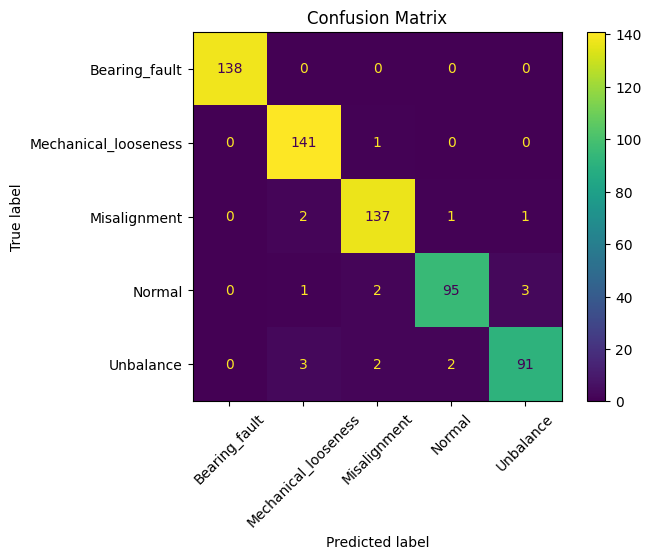

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

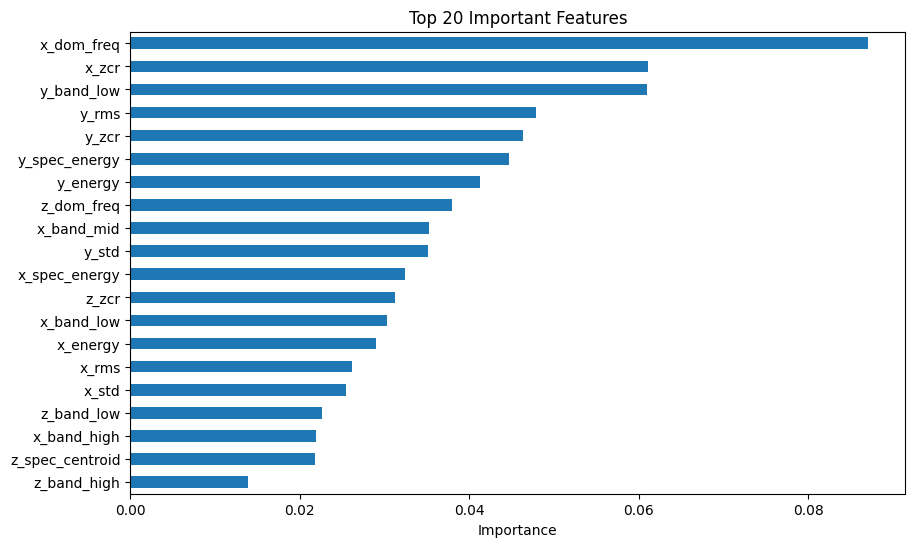

x_dom_freq         0.087106
x_zcr              0.061099
y_band_low         0.060935
y_rms              0.047921
y_zcr              0.046366
y_spec_energy      0.044735
y_energy           0.041308
z_dom_freq         0.037958
x_band_mid         0.035229
y_std              0.035103
x_spec_energy      0.032437
z_zcr              0.031184
x_band_low         0.030314
x_energy           0.028935
x_rms              0.026122
x_std              0.025448
z_band_low         0.022566
x_band_high        0.021906
z_spec_centroid    0.021771
z_band_high        0.013938
dtype: float64


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Important Features")
plt.xlabel("Importance")
plt.show()

print(importances.head(20))

Different faults produce different vibration frequencies such as:

unbalance → periodic frequency

misalignment → structured oscillation

bearing → broad spectrum

ZCR measures how often signal changes direction where:

High ZCR → noisy / chaotic signal (bearing fault)

Low ZCR → smooth periodic signal (misalignment)

Energy + RMS still matter (y_rms, y_energy, y_spec_energy) beacuse it captures vibration intensity.
Meaning:
High energy → strong faults and Low/moderate → normal / mild faults




In [22]:
compare_cols = [
    "x_rms", "y_rms", "z_rms",
    "x_kurtosis", "y_kurtosis", "z_kurtosis",
    "x_spec_energy", "y_spec_energy", "z_spec_energy"
]

df.groupby("label")[compare_cols].mean()

,x_rms,y_rms,z_rms,x_kurtosis,y_kurtosis,z_kurtosis,x_spec_energy,y_spec_energy,z_spec_energy
label,,,,,,,,,
Bearing_fault,78309.727727,159723.985179,47759.240906,69.222573,71.832391,61.079060,1.725840e+17,3.774299e+18,1.003307e+17
Mechanical_looseness,63809.613254,58504.699886,260220.036253,85.570641,82.572192,95.090444,1.397925e+17,1.214065e+17,7.245921e+18
Misalignment,52375.274958,80943.548668,35080.478290,59.996540,67.102059,60.875202,1.128122e+17,1.754240e+17,6.960249e+16
Normal,100287.846019,227356.546977,107644.605257,95.556643,109.287988,100.676765,2.174147e+17,5.039380e+18,2.336717e+17
Unbalance,139244.521496,181444.681928,114097.319929,109.398803,120.872176,129.663842,3.069442e+17,3.903993e+17,2.414169e+17


Bearing_fault: Moderate amplitude with broad spectral energy and elevated kurtosis indicates a chaotic, impact-driven vibration pattern.

Mechanical_looseness: Strong Z-axis energy with high kurtosis reflects localized impulsive vibrations due to structural instability.

Misalignment: Lower amplitude with moderate energy and smoother oscillatory behavior suggests a structured, periodic misalignment pattern.

Normal: High baseline energy with relatively stable waveform indicates consistent operational vibration without distinct fault signatures.

Unbalance: Highest amplitude and kurtosis with strong energy across axes indicates dominant periodic vibration with superimposed instability.

<Figure size 800x400 with 0 Axes>

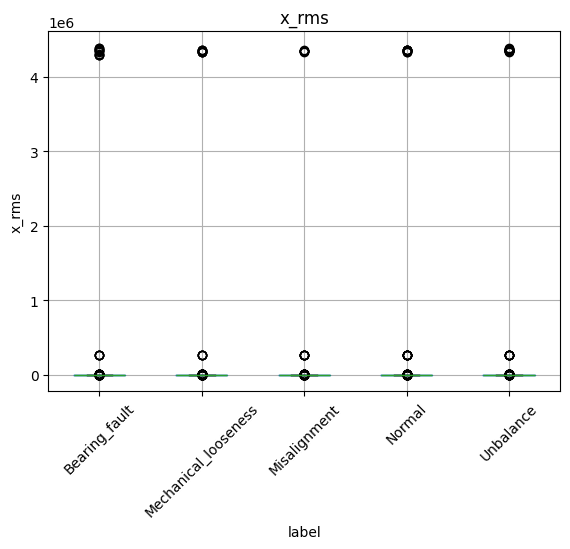

<Figure size 800x400 with 0 Axes>

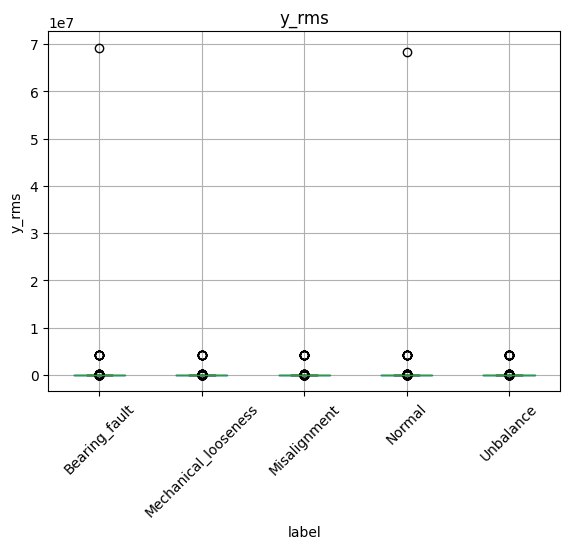

<Figure size 800x400 with 0 Axes>

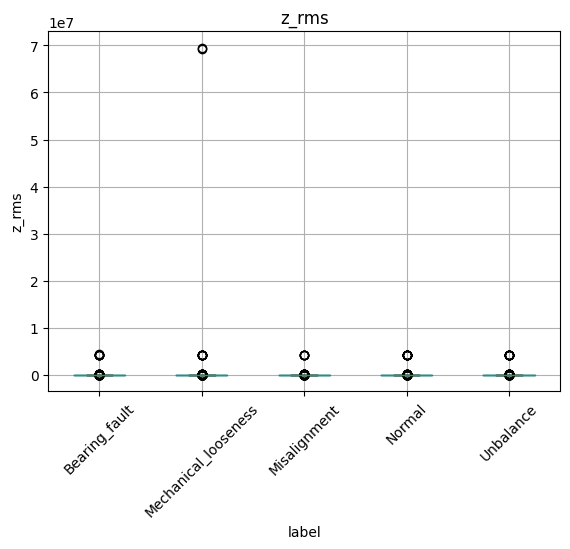

<Figure size 800x400 with 0 Axes>

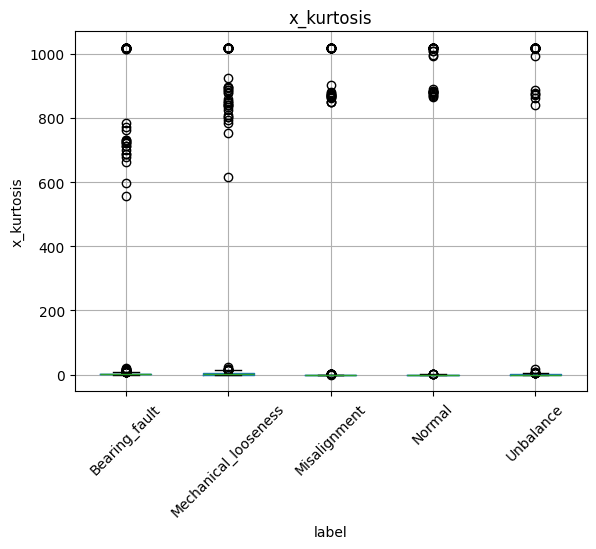

<Figure size 800x400 with 0 Axes>

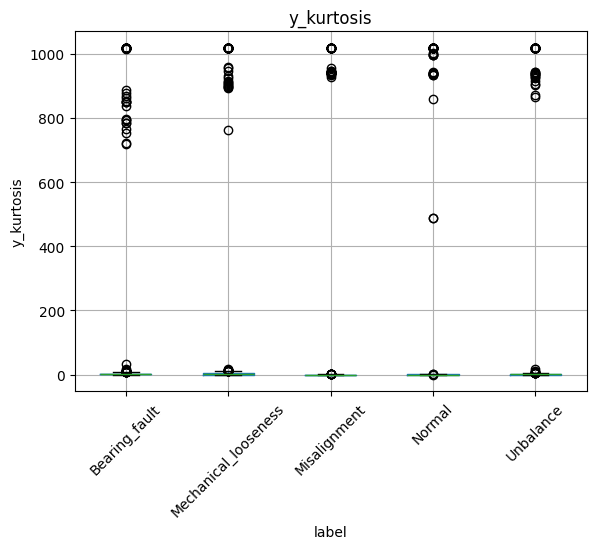

<Figure size 800x400 with 0 Axes>

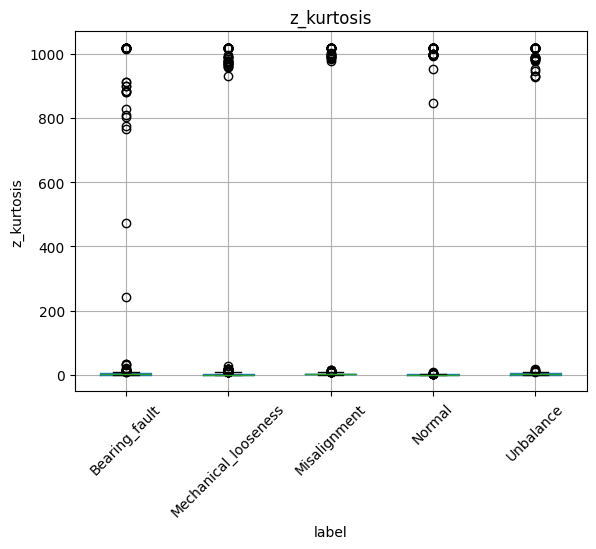

<Figure size 800x400 with 0 Axes>

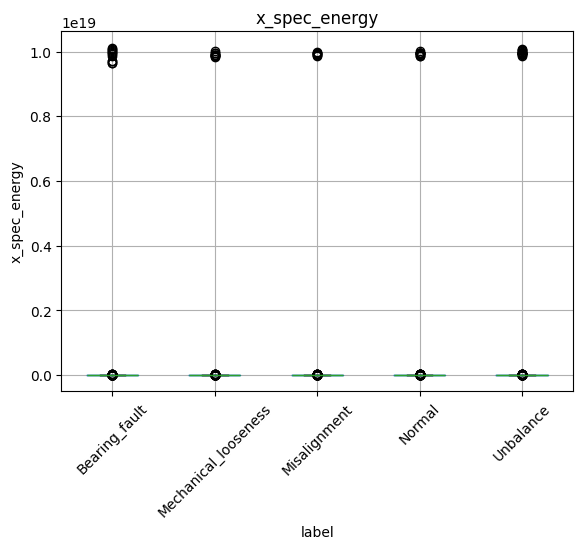

<Figure size 800x400 with 0 Axes>

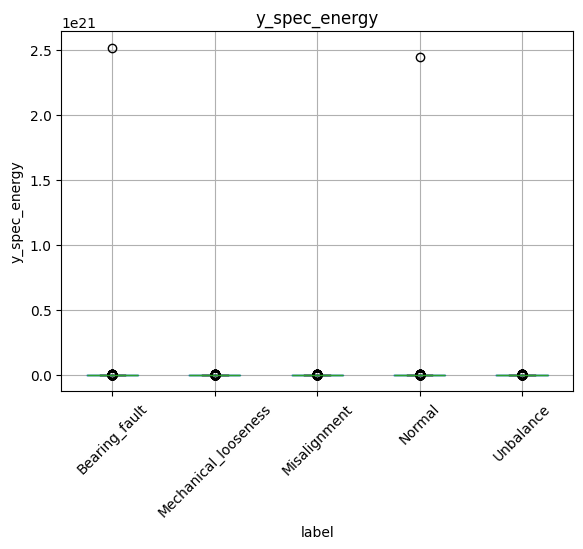

<Figure size 800x400 with 0 Axes>

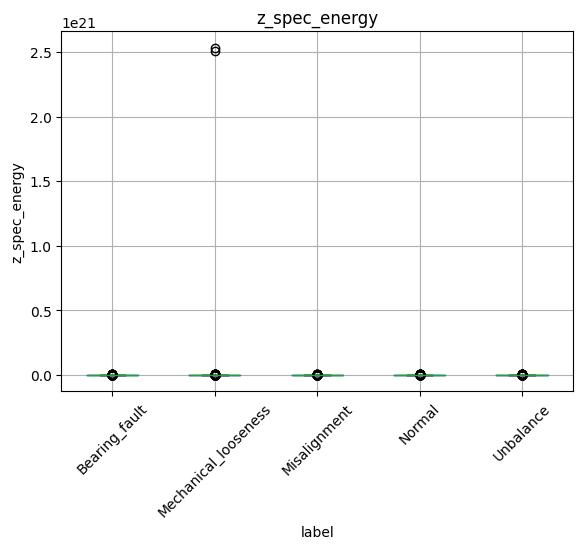

In [23]:
for col in compare_cols:
    plt.figure(figsize=(8,4))
    df.boxplot(column=col, by="label", rot=45)
    plt.title(col)
    plt.suptitle("")
    plt.ylabel(col)
    plt.show()


In [24]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y_encoded, cv=5, scoring="f1_weighted")

print("Cross-validation F1 scores:", scores)
print("Mean F1:", scores.mean())

Cross-validation F1 scores: [0.97111494 0.96933028 0.95913851 0.93913831 0.94501477]
Mean F1: 0.9567473626663023


In [26]:
df.to_csv("final_feature_dataset.csv", index=False)

In [27]:
import joblib

joblib.dump(rf, "fault_classifier_rf.pkl")

['fault_classifier_rf.pkl']

In [28]:
print("Final Summary:")
print("Accuracy:", rf.score(X_test, y_test))
print("Classes:", le.classes_)
print("Total samples:", len(df))
print("Total features:", X.shape[1])

Final Summary:
Accuracy: 0.9709677419354839
Classes: ['Bearing_fault' 'Mechanical_looseness' 'Misalignment' 'Normal'
 'Unbalance']
Total samples: 3097
Total features: 54


### SECOND PART: SEVERITY CHECK






In [29]:
import os
os.listdir("/content")

['.config',
 'Unbalanced_3000_High_15.jsonl',
 'Misalignment_state_2000rpm_10mins.jsonl',
 'fault_classifier_rf.pkl',
 'Normal_state_2000rpm_10mins.jsonl',
 'Bearing_fault_state_2000rpm_10mins.jsonl',
 'Unbalanced_3000_Low_15.jsonl',
 'final_feature_dataset.csv',
 'Unbalanced_2000_High_15.jsonl',
 'Unbalanced_2000_Low_15.jsonl',
 'Unbalanced_2000_Medium_15.jsonl',
 'Unbalance_state_2000rpm_10mins_with_4screws.jsonl',
 'Mechanical_looseness_state_2000rpm_10mins.jsonl',
 'sample_data']

In [33]:
files_severity = {
    "2000_Low": "/content/Unbalanced_2000_Low_15.jsonl",
    "2000_Medium": "/content/Unbalanced_2000_Medium_15.jsonl",
    "2000_High": "/content/Unbalanced_2000_High_15.jsonl",
    "3000_Low": "/content/Unbalanced_3000_Low_15.jsonl",
    "3000_Medium": "/content/Unbalanced_3000_Medium_15.jsonl",
    "3000_High": "/content/Unbalanced_3000_High_15.jsonl"
}

In [36]:
def parse_severity_label(key):
    rpm_str, severity = key.split("_")
    rpm = int(rpm_str)
    return rpm, severity

In [37]:
all_samples_severity = []

for key, path in files_severity.items():
    rpm, severity = parse_severity_label(key)

    rows = load_jsonl(path, "unbalance")
    samples = build_triaxial_samples(rows)

    for s in samples:
        s["rpm"] = rpm
        s["severity"] = severity
        all_samples_severity.append(s)

    print(f"{key}: {len(samples)} samples")

2000_Low: 816 samples
2000_Medium: 333 samples
2000_High: 1041 samples
3000_Low: 612 samples
3000_Medium: 1038 samples
3000_High: 1024 samples


In [38]:
print("Total severity samples:", len(all_samples_severity))
print("First sample keys:", all_samples_severity[0].keys())
print("First sample severity:", all_samples_severity[0]["severity"])
print("First sample rpm:", all_samples_severity[0]["rpm"])
print("Length X:", len(all_samples_severity[0]["x"]))
print("Length Y:", len(all_samples_severity[0]["y"]))
print("Length Z:", len(all_samples_severity[0]["z"]))

Total severity samples: 4864
First sample keys: dict_keys(['x', 'y', 'z', 'label', 'rpm', 'severity'])
First sample severity: Low
First sample rpm: 2000
Length X: 1024
Length Y: 1024
Length Z: 1024


In [39]:
feature_rows_severity = []

for s in all_samples_severity:
    row = {}

    # X axis features
    row.update(time_features(s["x"], "x"))
    row.update(frequency_features(s["x"], "x"))

    # Y axis features
    row.update(time_features(s["y"], "y"))
    row.update(frequency_features(s["y"], "y"))

    # Z axis features
    row.update(time_features(s["z"], "z"))
    row.update(frequency_features(s["z"], "z"))

    # metadata
    row["rpm"] = s["rpm"]
    row["severity"] = s["severity"]

    feature_rows_severity.append(row)

df_severity = pd.DataFrame(feature_rows_severity)

In [40]:
print("Shape:", df_severity.shape)

print("\nMissing values:")
print(df_severity.isna().sum().sort_values(ascending=False).head(10))

print("\nSeverity counts:")
print(df_severity["severity"].value_counts())

print("\nRPM counts:")
print(df_severity["rpm"].value_counts())

df_severity.head()

Shape: (4864, 56)

Missing values:
x_mean        0
x_std         0
x_rms         0
x_min         0
x_max         0
x_ptp         0
x_skew        0
x_kurtosis    0
x_energy      0
x_zcr         0
dtype: int64

Severity counts:
severity
High      2065
Low       1428
Medium    1371
Name: count, dtype: int64

RPM counts:
rpm
3000    2674
2000    2190
Name: count, dtype: int64


,x_mean,x_std,x_rms,x_min,x_max,x_ptp,x_skew,x_kurtosis,x_energy,x_zcr,...,z_crest_factor,z_shape_factor,z_dom_freq,z_spec_centroid,z_spec_energy,z_band_low,z_band_mid,z_band_high,rpm,severity
0,0.0,69.707633,69.707633,-184.410156,234.589844,419.0,0.298714,-0.048938,4.975774e+06,0.099609,...,3.553844,1.229151,0.006836,0.165391,1.786432e+09,1.393763e+09,3.309566e+08,6.171321e+07,2000,Low
1,0.0,60.917197,60.917197,-176.100586,184.899414,361.0,0.277675,0.184321,3.799967e+06,0.115234,...,4.685931,1.283638,0.056641,0.144774,2.535871e+09,2.220600e+09,2.571237e+08,5.814696e+07,2000,Low
2,0.0,75.596966,75.596966,-218.995117,293.004883,512.0,0.247721,0.904803,5.852059e+06,0.114258,...,3.998055,1.254822,0.006836,0.149338,1.719927e+09,1.425026e+09,2.551951e+08,3.970593e+07,2000,Low
3,0.0,76.511681,76.511681,-203.302734,286.697266,490.0,0.101453,-0.100536,5.994534e+06,0.127930,...,3.367684,1.262435,0.006836,0.147869,2.056180e+09,1.630240e+09,3.680136e+08,5.792610e+07,2000,Low
4,0.0,58.657123,58.657123,-160.738281,193.261719,354.0,0.214539,0.173665,3.523234e+06,0.145508,...,3.039526,1.245383,0.006836,0.165933,1.304164e+09,9.717668e+08,2.916121e+08,4.078481e+07,2000,Low


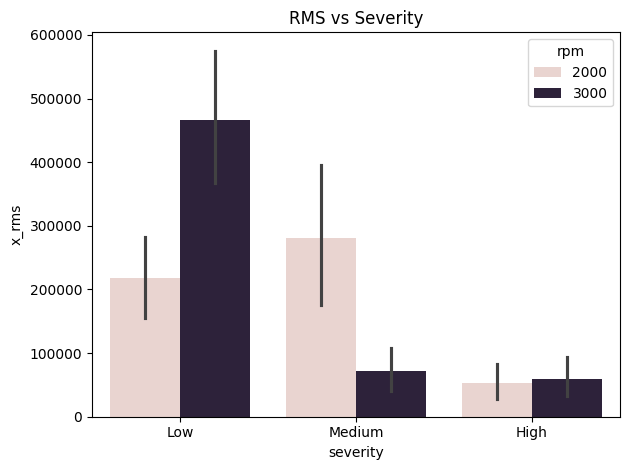

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x="severity",
    y="x_rms",
    hue="rpm",
    data=df_severity,
    order=["Low", "Medium", "High"]
)

plt.title("RMS vs Severity")
plt.tight_layout()
plt.show()

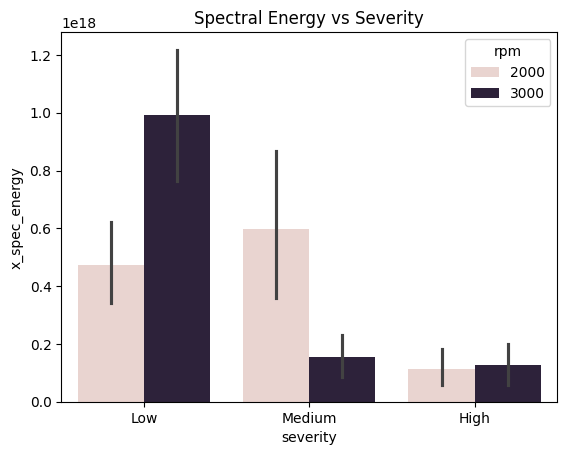

In [46]:
sns.barplot(
    x="severity",
    y="x_spec_energy",
    hue="rpm",
    data=df_severity,
    order=["Low", "Medium", "High"]
)

plt.title("Spectral Energy vs Severity")
plt.show()

<Axes: xlabel='severity', ylabel='y_rms'>

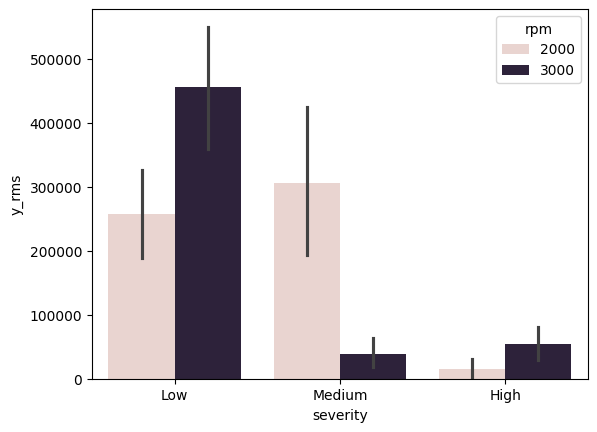

In [47]:
sns.barplot(x="severity", y="y_rms", hue="rpm", data=df_severity, order=["Low","Medium","High"])

<Axes: xlabel='severity', ylabel='z_rms'>

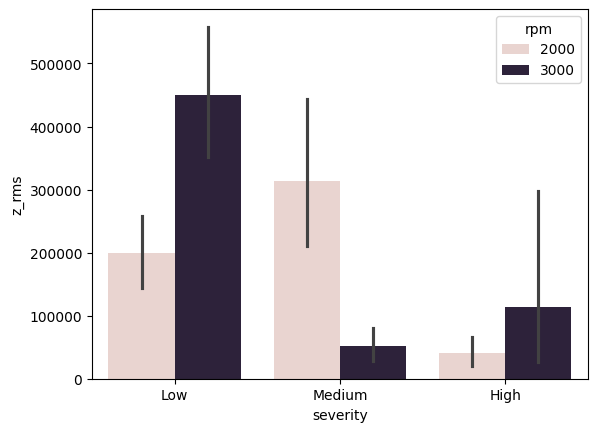

In [48]:
sns.barplot(x="severity", y="z_rms", hue="rpm", data=df_severity, order=["Low","Medium","High"])

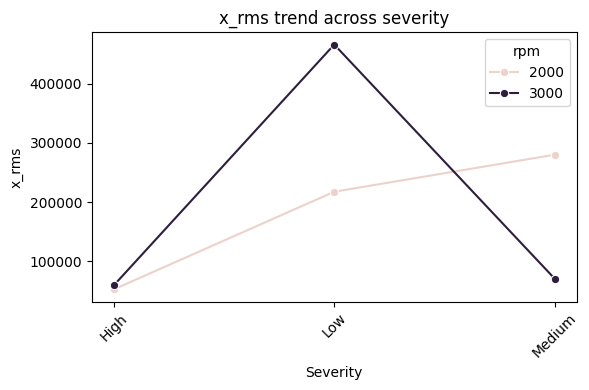

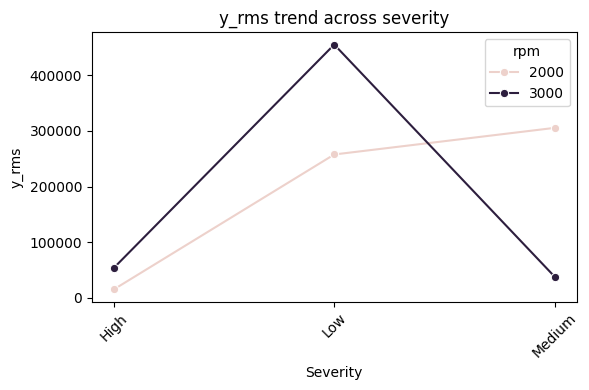

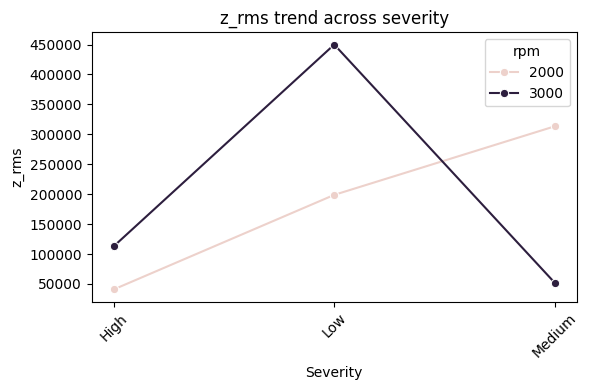

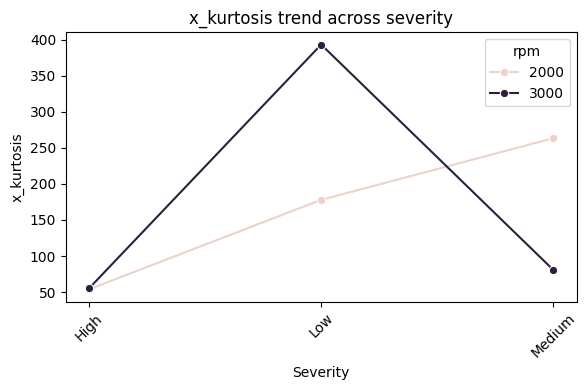

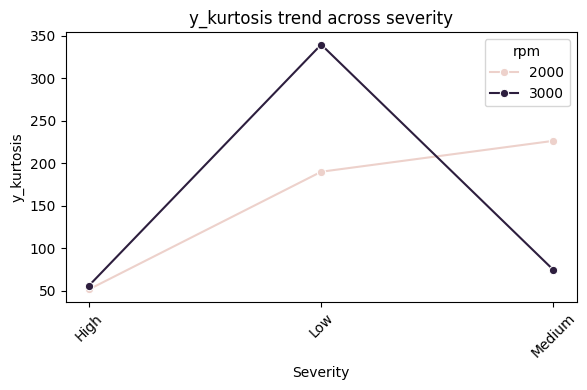

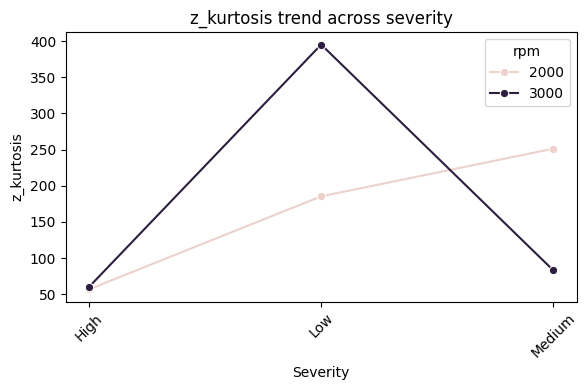

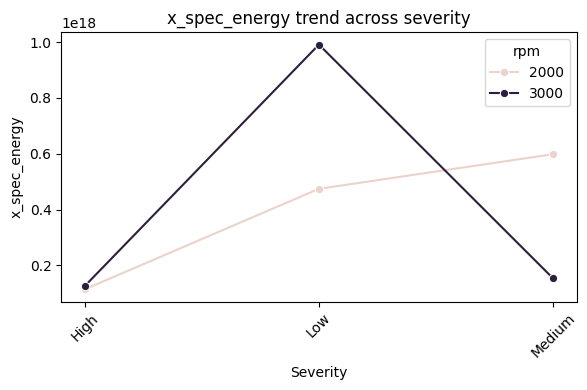

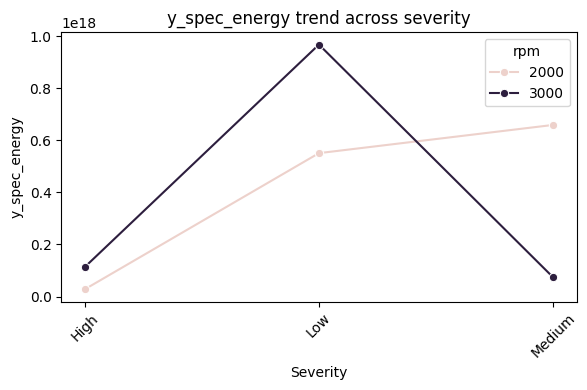

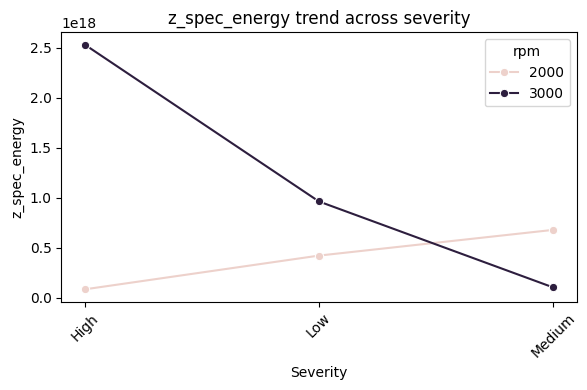

In [44]:
#### mean trend plot
import seaborn as sns
import matplotlib.pyplot as plt

severity_order = ["Low", "Medium", "High"]

for col in compare_cols_severity:
    plt.figure(figsize=(6,4))
    sns.lineplot(
        data=mean_df,
        x="severity",
        y=col,
        hue="rpm",
        marker="o",
        sort=False
    )
    plt.title(f"{col} trend across severity")
    plt.xlabel("Severity")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [49]:
df_2000 = df_severity[df_severity["rpm"] == 2000].copy()
df_3000 = df_severity[df_severity["rpm"] == 3000].copy()

print("2000 shape:", df_2000.shape)
print(df_2000["severity"].value_counts())

print("\n3000 shape:", df_3000.shape)
print(df_3000["severity"].value_counts())

2000 shape: (2190, 56)
severity
High      1041
Low        816
Medium     333
Name: count, dtype: int64

3000 shape: (2674, 56)
severity
Medium    1038
High      1024
Low        612
Name: count, dtype: int64


In [51]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

def run_severity_model(df_rpm, rpm_name):
    X = df_rpm.drop(columns=["severity"])
    y = df_rpm["severity"]

    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    print(f"\n===== RPM {rpm_name} =====")
    print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_encoded,
        test_size=0.2,
        random_state=42,
        stratify=y_encoded
    )

    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot()
    plt.title(f"Severity Confusion Matrix - RPM {rpm_name}")
    plt.tight_layout()
    plt.show()

    importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    importances.head(15).sort_values().plot(kind="barh")
    plt.title(f"Top 15 Features - RPM {rpm_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    print("\nTop 15 features:")
    print(importances.head(15))

    cv_scores = cross_val_score(rf, X, y_encoded, cv=5, scoring="f1_weighted")
    print("\n5-fold weighted F1 scores:", cv_scores)
    print("Mean weighted F1:", cv_scores.mean())
    print("Std:", cv_scores.std())

    return rf, le, importances


===== RPM 2000 =====
Label mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

Classification Report:
              precision    recall  f1-score   support

        High       0.69      0.81      0.75       208
         Low       0.67      0.66      0.66       163
      Medium       0.89      0.49      0.63        67

    accuracy                           0.70       438
   macro avg       0.75      0.65      0.68       438
weighted avg       0.72      0.70      0.70       438



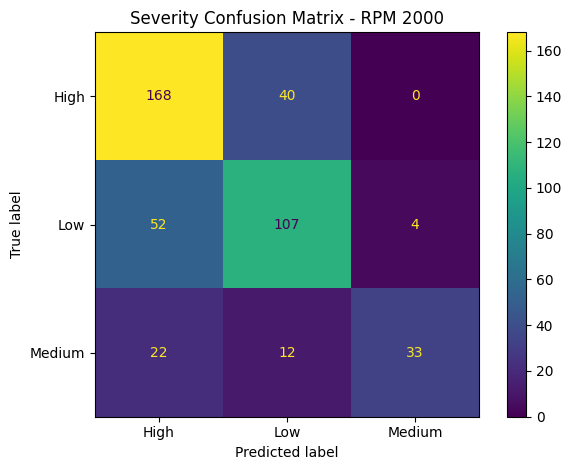

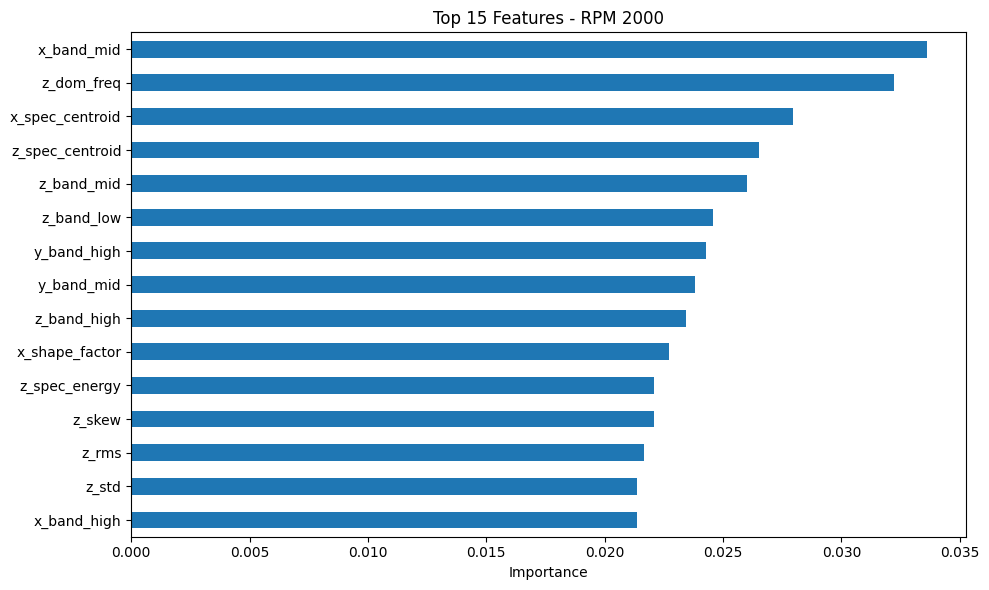


Top 15 features:
x_band_mid         0.033599
z_dom_freq         0.032200
x_spec_centroid    0.027935
z_spec_centroid    0.026505
z_band_mid         0.026022
z_band_low         0.024576
y_band_high        0.024266
y_band_mid         0.023806
z_band_high        0.023439
x_shape_factor     0.022726
z_spec_energy      0.022102
z_skew             0.022080
z_rms              0.021643
z_std              0.021380
x_band_high        0.021358
dtype: float64

5-fold weighted F1 scores: [0.53728183 0.64359091 0.75666298 0.72654655 0.75288576]
Mean weighted F1: 0.6833936068002828
Std: 0.0836572100756404


In [52]:
rf_2000, le_2000, imp_2000 = run_severity_model(df_2000, 2000)


===== RPM 3000 =====
Label mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       205
         Low       0.92      0.95      0.94       122
      Medium       0.97      0.95      0.96       208

    accuracy                           0.97       535
   macro avg       0.96      0.97      0.96       535
weighted avg       0.97      0.97      0.97       535



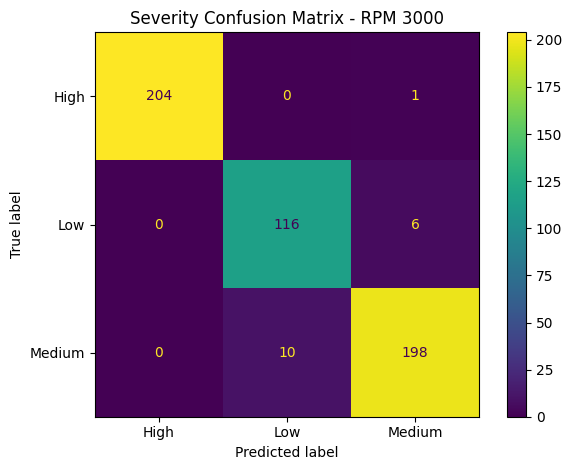

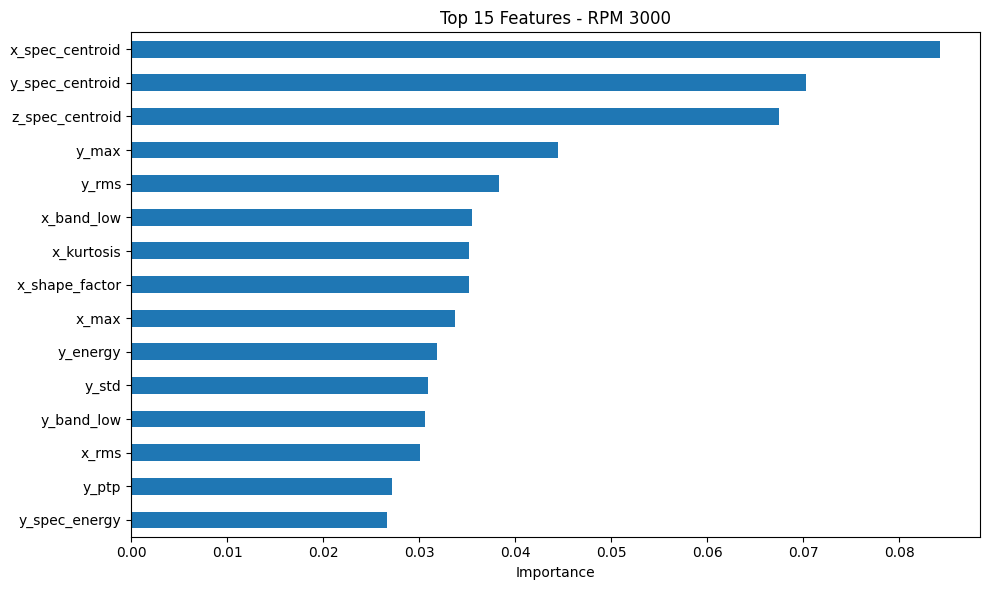


Top 15 features:
x_spec_centroid    0.084206
y_spec_centroid    0.070276
z_spec_centroid    0.067503
y_max              0.044474
y_rms              0.038272
x_band_low         0.035489
x_kurtosis         0.035220
x_shape_factor     0.035159
x_max              0.033758
y_energy           0.031818
y_std              0.030929
y_band_low         0.030626
x_rms              0.030058
y_ptp              0.027131
y_spec_energy      0.026676
dtype: float64

5-fold weighted F1 scores: [0.92497347 0.95185552 0.98321863 0.94605957 0.97201722]
Mean weighted F1: 0.9556248848079683
Std: 0.0203731968175066


In [54]:
rf_3000, le_3000, imp_3000 = run_severity_model(df_3000, 3000)

Severity classification performance varied significantly with rotational speed. At 3000 RPM, the model achieved near-perfect accuracy (~97%), whereas at 2000 RPM performance dropped to ~70%, indicating that fault severity is more distinguishable at higher operating speeds.

In [55]:
print("Summary:")
print("2000 RPM Accuracy ~70% → poor separation")
print("3000 RPM Accuracy ~97% → strong separation")
print("Conclusion: Severity classification improves with RPM")

Summary:
2000 RPM Accuracy ~70% → poor separation
3000 RPM Accuracy ~97% → strong separation
Conclusion: Severity classification improves with RPM


In [56]:
X = df_severity.drop(columns=["severity"])
y = df_severity["severity"]

In [57]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Label mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [60]:
from sklearn.metrics import classification_report

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

        High       0.86      0.91      0.88       413
         Low       0.82      0.82      0.82       286
      Medium       0.96      0.86      0.91       274

    accuracy                           0.87       973
   macro avg       0.88      0.86      0.87       973
weighted avg       0.87      0.87      0.87       973



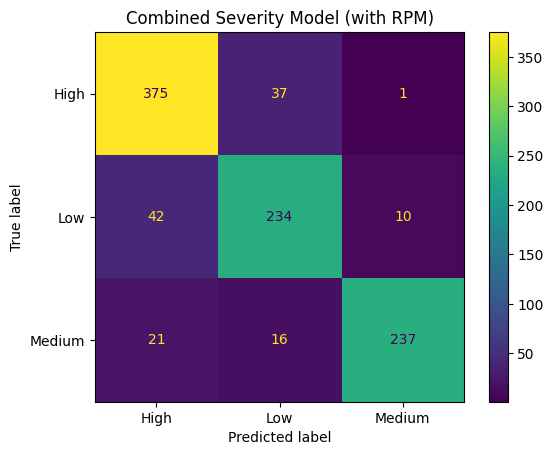

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot()
plt.title("Combined Severity Model (with RPM)")
plt.show()

Severity classes show partial overlap, particularly between High and Low, but inclusion of RPM significantly improves separability, achieving overall strong performance (~87%).

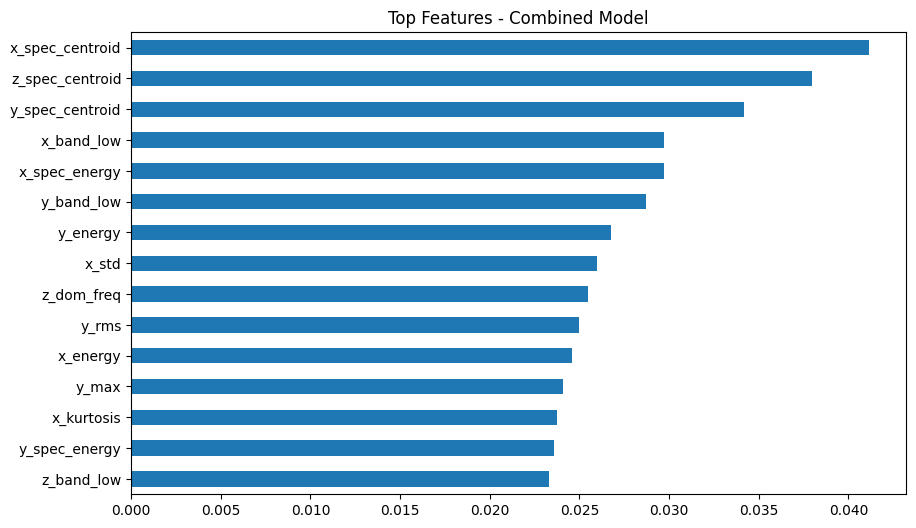

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(15).sort_values().plot(kind="barh")
plt.title("Top Features - Combined Model")
plt.show()